# Evaluation of Translation Models

## 1 Overview

The NLLB-200, M2M100, and SeamlessM4T multilingual machine-translation models are compared in this notebook using the processed OPUS-100 dataset [1] for the three non-English languages that the application supports Tamil, Chinese, and Malay. Every model translates 100 sentences per language each split from English into each target language.

In addition to recording BLEU, loading time, and inference time, models are compared on the validation split and the best candidate is chosen using average chrF++ as the primary metric. Because its character-n-gram matching is more dependable than word-level BLEU for morphologically rich and non-space-segmented languages (like Chinese), where BLEU can be extremely low even for excellent translations, chrF++ is selected as the main metric. On the reserved test split, only the chosen model is assessed. There is no fine-tuning or training done.

## 2 Importing Libraries

This section imports the toolchain for the machine-translation evaluation. Because each of the three candidates NLLB-200, M2M100, and SeamlessM4T uses a separate tokenizer and generation interface and cannot share a single pipeline, dedicated Hugging Face model and tokenizer classes are imported. The results are directly comparable with published work because sacreBLEU provide the chrF++ and BLEU scores, which are the standard, repeatable implementations used in the translation literature. Torch provides the tensor backend, mixed-precision option, and GPU access; Matplotlib creates the comparison graphic and pandas organises the data and outcomes. The standard-library gc, random, and time modules manage timing, seeding, and memory cleanup in between large models.

In [1]:
# remove all warnings
import os
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
os.environ["HF_HUB_VERBOSITY"] = "error"

import warnings, logging
warnings.filterwarnings("ignore")
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
logging.getLogger("transformers").setLevel(logging.ERROR)

In [2]:
# import required libraries
import gc
import random
import time
from pathlib import Path
import pandas as pd
import torch
from datasets import load_dataset
from sacrebleu.metrics import BLEU, CHRF
import matplotlib.pyplot as plt
from transformers import AutoModelForSeq2SeqLM, AutoProcessor, AutoTokenizer, M2M100ForConditionalGeneration, M2M100Tokenizer, SeamlessM4TForTextToText

Once these imports are set up, the notebook can load the OPUS-100 pairs, translate them using three distinct multilingual models, and score the results against self-contained reference implementations. Because BLEU is famously sensitive to tokenization, using sacreBLEU instead of an ad hoc BLEU maintains the numbers fair and comparable. The warning about the tqdm widget is only decorative. The shared settings are fixed and the candidate models are registered in the next section.

## 3 Evaluation Settings and Candidate Models

In this part, the candidates are listed and the experimental conditions are specified. The device and mixed-precision dtype half precision on the GPU to suit the larger models and full precision on the CPU for stability are chosen, along with a random seed, test and validation sizes, and a special output folder. Each of the three registered many-to-many multilingual translation models has a batch size that is specific to its memory footprint.

In [3]:
# set SEED to 42
SEED = 42

In [4]:
# random seed
random.seed(SEED)
# seed PyTorch for reproducibility
torch.manual_seed(SEED)

In [5]:
# call torch devide
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# compute dtype
dtype = (torch.float16 if torch.cuda.is_available() else torch.float32)

In [6]:
# validation and test size
VALIDATION_SIZE = 100
TEST_SIZE = 100

In [7]:
# output folder
output_folder = Path("outputs/translation")
# create the folder
output_folder.mkdir(parents=True, exist_ok=True)

In [8]:
# define models
models = {
    # NLLB-200 model
    "NLLB-200": {
        "model_id": "facebook/nllb-200-distilled-600M",
        "batch_size": 8
    },

    # M2M100 model
    "M2M100": {
        "model_id": "facebook/m2m100_418M",
        "batch_size": 8
    },

    # SeamlessM4T model
    "SeamlessM4T": {
        "model_id": "facebook/hf-seamless-m4t-medium",
        "batch_size": 2
    }
}

In [9]:
# define languages list
languages = ["Malay", "Chinese", "Tamil"]

In [10]:
# print statements
print("Models:", len(models))
print("Languages:", languages)

Models: 3
Languages: ['Malay', 'Chinese', 'Tamil']


In [11]:
# model information list
model_information = []

In [12]:
for model_name, details in models.items():
    # model information append to list
    model_information.append({
        "Model": model_name,
        "Model ID": details["model_id"]
    })

In [13]:
# model information dataframe
model_information_df = pd.DataFrame(model_information)
model_information_df

,Model,Model ID
0,NLLB-200,facebook/nllb-200-distilled-600M
1,M2M100,facebook/m2m100_418M
2,SeamlessM4T,facebook/hf-seamless-m4t-medium


These definitions are the only place where model selections are made. Each part that follows repeats them under a single method, ensuring that the comparison between three quite diverse translation systems is fair. A useful detail that enables the same notebook to function appropriately on a CPU and efficiently on a GPU is choosing the precision by device. Fixing the evaluation sizes keeps runtime manageable while remaining representative of the application's supported languages. The notebook loads the evaluation data after the settings are configured.

## 4 Load Processed OPUS-100 Evaluation Data

For the three non-English languages the program supports Malay, Chinese, and Tamil this portion loads the cleaned OPUS-100 validation and test phrase pairs, storing the English sources and reference translations for each language. The per-language counts are printed and one worked example per language is displayed so the English source can be seen paired with its correct reference. Loading a pre-cleaned version of OPUS-100 rather than the raw corpus means noisy or misaligned pairs have already been removed upstream.

In [14]:
# processed folder
processed_folder = Path("../../data/processed/opus100_translation")
#validation folder
validation_folder = (processed_folder / "validation")
# testing folder
testing_folder = (processed_folder / "testing")

In [15]:
# validation data
validation_data = {}
# testing data
testing_data = {}

In [16]:
for language in languages:
    # filenemae
    filename = (language.lower() + ".csv")
    # validation dataframe
    validation_df = pd.read_csv(validation_folder / filename)
    # testing dataframe
    testing_df = pd.read_csv(testing_folder / filename)
    # validation data language
    validation_data[language] = {
        "source": validation_df["source"].tolist(),
        "reference":validation_df["reference"].tolist()
    }

    # testing data language
    testing_data[language] = {
        "source": testing_df["source"].tolist(),
        "reference": testing_df["reference"].tolist()
    }
# print statement
print("Clean OPUS-100 evaluation data loaded")

Clean OPUS-100 evaluation data loaded


In [17]:
# print validation samples
print("Validation samples")
for language in languages:
    print(language,len(validation_data[language]["source"]))

Validation samples
Malay 100
Chinese 100
Tamil 100


In [18]:
# print test samples
print("\nTest samples")
for language in languages:
    print(language,len(testing_data[language]["source"]))


Test samples
Malay 100
Chinese 100
Tamil 100


In [19]:
for language in languages:
    # print language, source and reference
    print(f"\n{language}")
    print("English:",validation_data[language]["source"][0])
    print("Reference:",validation_data[language]["reference"][0])


Malay
English: You have killed his enemy... and his suspicions.
Reference: Awak telah membunuh musuh dia... dan juga perasaan syak wasangkanya.

Chinese
English: These efforts were duly reflected in Guatemala's participation in the Commission on Human Rights, and we pledge to sustain them in the future work of the Human Rights Council.
Reference: 这些努力正确反映于危地马拉参加人权委员会，我们保证将来在人权理事会继续这样努力。

Tamil
English: Fix stair-stepping text
Reference: படிக்கட்டான உரையைச் சரிசெய்


**Analysis:** 

Each of the three splits loads 100 sentence pairs in Tamil, Chinese, and Malay, for a total of 600 pairs. The worked examples verify that the alignment is accurate and demonstrate the spectrum of difficulty the references cover Latin (Malay), Han (Chinese), and Tamil scriptsthe precise multilingual spread the program must handle while some sources are complete sentences and others are brief UI snippets.

Verifying the counts and alignment in advance across three different scripts Latin for Malay, Han for Chinese, and Tamil script for Tamil ensures that any subsequent quality discrepancy can be assigned to the models rather than a data issue. The worked examples also show the range of difficulty, from complete sentences to brief interface strings. When translating English recommendations, assistant replies and interface text into Malay, Chinese and Tamil, the application needs to manage precisely this multilingual dispersion. The disparate language-code schemes of the models are reconciled in the following section.

## 5 Language Code Alignment

This section generates a table mapping each target language to the appropriate code for each of the three models, each of which identifies languages with its own code scheme Malay is zsm_Latn in NLLB-200, ms in M2M100 and zsm in SeamlessM4T, and Chinese and Tamil differ similarly. Centralising these codes in one structure removes the risk of a model silently translating into the wrong language.

In [20]:
# define language codes
language_codes = {
    # malay
    "Malay": {
        "NLLB-200": "zsm_Latn",
        "M2M100": "ms",
        "SeamlessM4T": "zsm"
    },

    # chinese
    "Chinese": {
        "NLLB-200": "zho_Hans",
        "M2M100": "zh",
        "SeamlessM4T": "cmn"
    },

    # tamil
    "Tamil": {
        "NLLB-200": "tam_Taml",
        "M2M100": "ta",
        "SeamlessM4T": "tam"
    }
}

With the codes aligned, every model is guaranteed to translate into the intended target language, which is a precondition for a fair comparison: a mismatched code would produce fluent output in the wrong language and a catastrophic, meaningless score. It is precisely this kind of detail that distinguishes an accurate multilingual evaluation from a somewhat flawed one handling the three schemes directly instead of assuming a shared norm. The scoring is explained in the next section.

## 6 Evaluation Method

This section outlines the scoring and generation process for translations. Quality is measured with sacreBLEU's chrF++, which compares character n-grams together with word order, and BLEU, which compares word n-grams. A batching helper forms fixed-size batches for efficient generation, and a scoring helper computes both metrics per language and records inference time. The per-language information that a single aggregate would conceal is preserved by calculating corpus-level scores for each language.

In [21]:
# bleu metric
bleu_metric = BLEU()

In [22]:
# chrf metric
chrf_metric = CHRF(word_order=2)

In [23]:
# calculate the translation metric
def calculate_translation_metrics(predictions,references):
    # bleu score
    bleu_score = bleu_metric.corpus_score(predictions,[references]).score
    # chrf score
    chrf_score = chrf_metric.corpus_score(predictions,[references]).score
    return chrf_score, bleu_score

In [24]:
# create the batches
def create_batches(data, batch_size):
    # loop over range
    for start in range(0, len(data), batch_size):
        yield data[start:start + batch_size]

In [25]:
# evaluate the predictions
def evaluate_predictions(model_name,predictions,data,inference_time):
    # results list
    results = []
    for language in languages:
        # compute chrf score, bleu score
        chrf_score, bleu_score = (calculate_translation_metrics(predictions[language],data[language]["reference"]))
        # sample count
        sample_count = len(data[language]["source"])
        # results append to list
        results.append({
            "model": model_name,
            "language": language,
            "chrF++": chrf_score,
            "BLEU": bleu_score,
            "inference_time": inference_time[language],
            "ms_per_sentence":inference_time[language] / sample_count * 1000
        })
    # return dataframe
    return pd.DataFrame(results)

Because its character level matching is significantly more dependable than word-level BLEU for morphologically rich and non-space-segmented languages, particularly Chinese, where BLEU can collapse toward zero even for an adequate translation, chrF++ is chosen as the main metric. While the primary rating is based on the more reliable measure, including BLEU as a secondary reference keeps the results readable for readers who anticipate it. The deployment related cost trade-off is captured by timing generation in conjunction with quality. The models can be assessed once the score has been established.

## 7 Evaluating Candidate Models on Validation Data

Each model is loaded and ran over the validation pairings for each of the three languages in this stage. Each model has a unique function that records the per-language chrF++, BLEU, and time and manages its specific tokenizer and generation call, including how each one correctly forces the target language. The three systems actually differ in how they are driven, but they all provide results in the same shape, thus it is necessary to give each model its own routine.

In [26]:
# evaluate the nllb model
def evaluate_nllb(data):
    # model id
    model_id = models["NLLB-200"]["model_id"]
    # batch size
    batch_size = models["NLLB-200"]["batch_size"]
    # start
    start = time.perf_counter()
    # tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_id,src_lang="eng_Latn")
    # model from pretrained
    model = AutoModelForSeq2SeqLM.from_pretrained(model_id,dtype=dtype).to(device)
    # switch model to evaluation mode
    model.eval()
    # loading time
    loading_time = time.perf_counter() - start
    # define predictions
    predictions = {}
    # define inference times
    inference_times = {}
    for language in languages:
        # translated list
        translated = []
        start = time.perf_counter()
        # target id
        target_id = tokenizer.convert_tokens_to_ids(language_codes[language]["NLLB-200"])
        for batch in create_batches(data[language]["source"],batch_size):
            # inputs for tokenizer
            inputs = tokenizer(batch,return_tensors="pt",padding=True,truncation=True,max_length=256).to(device)
            with torch.inference_mode():
                # model genereated outputs
                outputs = model.generate(**inputs,forced_bos_token_id=target_id,max_new_tokens=256)
            translated.extend(tokenizer.batch_decode(outputs,skip_special_tokens=True))
        # inference time
        inference_times[language] = time.perf_counter() - start
        predictions[language] = translated
    # run garbage collection
    gc.collect()

    # if a GPU is available
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # evaluate the predictinos
    results = evaluate_predictions("NLLB-200",predictions,data,inference_times)
    return results, loading_time, predictions

In [27]:
# results for the nllb
nllb_results, nllb_loading_time, nllb_predictions = evaluate_nllb(validation_data)
nllb_results

,model,language,chrF++,BLEU,inference_time,ms_per_sentence
0,NLLB-200,Malay,44.586308,20.495425,40.080137,400.801367
1,NLLB-200,Chinese,23.482352,1.529174,136.060657,1360.606574
2,NLLB-200,Tamil,32.536662,7.271271,83.946913,839.469131


In [28]:
# evluate the m2m100 morel
def evaluate_m2m100(data):
    # model if
    model_id = models["M2M100"]["model_id"]
    # batch size
    batch_size = models["M2M100"]["batch_size"]
    # start
    start = time.perf_counter()
    # tokenizer
    tokenizer = M2M100Tokenizer.from_pretrained(model_id)
    # model from pretrained
    model = M2M100ForConditionalGeneration.from_pretrained(model_id,dtype=dtype).to(device)
    # switch model to evaluation mode
    model.eval()
    # loading time
    loading_time = time.perf_counter() - start
    # define predictions
    predictions = {}
    # define inference times
    inference_times = {}
    for language in languages:
        # translated list
        translated = []
        tokenizer.src_lang = "en"
        # target id
        target_id = tokenizer.get_lang_id(language_codes[language]["M2M100"])
        start = time.perf_counter()
        for batch in create_batches(data[language]["source"],batch_size):
            # inputs for tokenizer
            inputs = tokenizer(batch,return_tensors="pt", padding=True,truncation=True,max_length=256).to(device)
            with torch.inference_mode():
                # model generated outputs
                outputs = model.generate(**inputs,forced_bos_token_id=target_id,max_new_tokens=256)
            translated.extend(tokenizer.batch_decode(outputs,skip_special_tokens=True))
        # inference time
        inference_times[language] = time.perf_counter() - start
        # predictions
        predictions[language] = translated
    # run garbage collection
    gc.collect()
    # if a GPU is available
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    # evaluate predictions
    results = evaluate_predictions("M2M100",predictions,data,inference_times)
    return results, loading_time, predictions

In [29]:
# M2M100 results
m2m100_results, m2m100_loading_time, m2m100_predictions = evaluate_m2m100(validation_data)
m2m100_results

,model,language,chrF++,BLEU,inference_time,ms_per_sentence
0,M2M100,Malay,41.719917,13.922079,85.708220,857.082195
1,M2M100,Chinese,22.318799,2.136142,380.872867,3808.728666
2,M2M100,Tamil,22.801511,8.102596,202.085057,2020.850574


In [30]:
# evaluate seamless
def evaluate_seamless(data):
    # model id
    model_id = models["SeamlessM4T"]["model_id"]
    # batch size
    batch_size = models["SeamlessM4T"]["batch_size"]
    # start
    start = time.perf_counter()
    # processoer from pretrained
    processor = AutoProcessor.from_pretrained(model_id)
    # model from pretrained
    model = SeamlessM4TForTextToText.from_pretrained(model_id,dtype=dtype).to(device)
    # switch model to evaluation mode
    model.eval()
    # loading time
    loading_time = time.perf_counter() - start
    # define predictions
    predictions = {}
    # define inference times
    inference_times = {}
    for language in languages:
        # translated list
        translated = []
        start = time.perf_counter()
        for batch in create_batches(data[language]["source"],batch_size):
            # inputs for the processor
            inputs = processor(text=batch,src_lang="eng",return_tensors="pt",padding=True).to(device)
            with torch.inference_mode():
                # model generated outputs
                outputs = model.generate(**inputs,tgt_lang=language_codes[language]["SeamlessM4T"],max_new_tokens=256)
            translated.extend(processor.batch_decode(outputs,skip_special_tokens=True))
        # inference time
        inference_times[language] = time.perf_counter() - start
        # predictions
        predictions[language] = translated
    # run garbage collection
    gc.collect()

    # if a GPU is available
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    # evaluate predictions
    results = evaluate_predictions("SeamlessM4T",predictions,data,inference_times)
    return results, loading_time, predictions

In [31]:
# SeamlessM4T results
seamless_results, seamless_loading_time, seamless_predictions = evaluate_seamless(validation_data)
seamless_results

,model,language,chrF++,BLEU,inference_time,ms_per_sentence
0,SeamlessM4T,Malay,41.939512,17.920507,72.506911,725.069105
1,SeamlessM4T,Chinese,20.265812,0.991494,387.276848,3872.768476
2,SeamlessM4T,Tamil,28.282140,6.622359,280.960445,2809.604449


In [32]:
# validation results concatenate
validation_results_df = pd.concat([nllb_results,m2m100_results,seamless_results],ignore_index=True)

In [33]:
# validation results dataframe
validation_results_df

,model,language,chrF++,BLEU,inference_time,ms_per_sentence
0,NLLB-200,Malay,44.586308,20.495425,40.080137,400.801367
1,NLLB-200,Chinese,23.482352,1.529174,136.060657,1360.606574
2,NLLB-200,Tamil,32.536662,7.271271,83.946913,839.469131
3,M2M100,Malay,41.719917,13.922079,85.708220,857.082195
4,M2M100,Chinese,22.318799,2.136142,380.872867,3808.728666
5,M2M100,Tamil,22.801511,8.102596,202.085057,2020.850574
6,SeamlessM4T,Malay,41.939512,17.920507,72.506911,725.069105
7,SeamlessM4T,Chinese,20.265812,0.991494,387.276848,3872.768476
8,SeamlessM4T,Tamil,28.282140,6.622359,280.960445,2809.604449


In order to maintain the final figure's integrity, only the validation data is used. The reserved test split remains unchanged until a single model is selected. The complete grid of results that the following section aggregates and ranks is created by scoring each language for each model. The analysis highlights the areas where the models differ most, which are previously indicated by the per-language figures. The selection and comparison come next.

## 8 Comparing and Selecting the Best Model

This section shows the comparison and chooses the best candidate after averaging each model's results across the three languages and ranking them by chrF++ using BLEU and speed as tie-breakers. Before ranking, averaging across languages ensures that the selected model is robust throughout the entire language set, as opposed to being strong in one language and poor in another.

In [34]:
# define loading times
loading_times = {"NLLB-200": nllb_loading_time,"M2M100": m2m100_loading_time,"SeamlessM4T": seamless_loading_time}

In [35]:
# comparison results list
comparison_results = []

In [36]:
for model_name in models:
    # compute results
    results = validation_results_df[validation_results_df["model"] == model_name]
    # comparison results append to the list
    comparison_results.append({
        "Model": model_name,
        "Average chrF++": results["chrF++"].mean(),
        "Average BLEU": results["BLEU"].mean(),
        "Loading Time": loading_times[model_name],
        "Inference Time": results["inference_time"].sum(),
        "ms / sentence": results["ms_per_sentence"].mean()
    })

In [37]:
# comparison dataframe results
comparison_df = pd.DataFrame(comparison_results)

In [38]:
# comparison dataframe sort values
comparison_df = comparison_df.sort_values(["Average chrF++","Average BLEU","Inference Time"],ascending=[False,False,True]).reset_index(drop=True)
comparison_df

,Model,Average chrF++,Average BLEU,Loading Time,Inference Time,ms / sentence
0,NLLB-200,33.535107,9.765290,4.301975,260.087707,866.959024
1,SeamlessM4T,30.162488,8.511453,12.046337,740.744203,2469.147343
2,M2M100,28.946742,8.053606,3.713441,668.666144,2228.887145


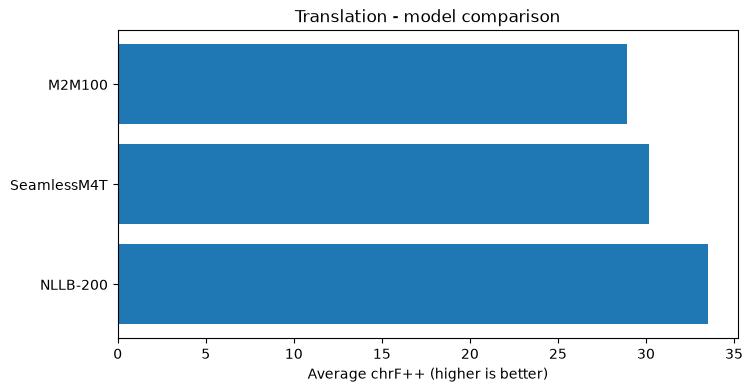

In [39]:
# bar graph for model comparison
plt.figure(figsize=(8, 4))
plt.barh(comparison_df["Model"],comparison_df["Average chrF++"])
plt.xlabel("Average chrF++ (higher is better)")
plt.title("Translation - model comparison")
plt.show()

**Analysis:** 

With the greatest average chrF++ of 33.54 and average BLEU of 9.77, NLLB-200 outperforms SeamlessM4T (30.16 / 8.51) and M2M100 (28.95 / 8.05). The ranking is explained by the per-language validation results all models handle Malay best (NLLB chrF++ 44.59, BLEU 20.50) and Chinese worst (NLLB's Chinese BLEU is only 1.53 despite a chrF++ of 23.48), which is precisely the BLEU-versus-chrF++ divergence that drives the use of chrF++ as the main metric for non space segmented text. NLLB-200 is chosen because it is the fastest of the three, averaging roughly 867 milliseconds per phrase.

In [40]:
# print selected model
selected_model_name = comparison_df.loc[0,"Model"]
print("Selected model:", selected_model_name)
print("Model ID:", models[selected_model_name]["model_id"])

Selected model: NLLB-200
Model ID: facebook/nllb-200-distilled-600M


The test result assesses generalisation rather than modification, since the chosen model then proceeds to the next test split unchanged. There is no need to compromise between quality and speed because ranking largely on chrF++ implements the metric decision made previously and, in this case, also chooses the fastest model. The deployed application, which uses a single translation model for all English-to-Malay, Chinese and Tamil output, is consistent with committing to a single model. The decision regarding held-out data is validated in the following section.

## 9 Final Test Evaluation

This part presents the model's per-language and averaged chrF++ and BLEU and assesses only the chosen model on the reserved test split. The test pairs are directly comparable to the validation because they are rated using the same methodology and metrics.

In [41]:
# if selected model is NLLB-200
if selected_model_name == "NLLB-200":
    test_results_df, test_loading_time, test_predictions = evaluate_nllb(testing_data)
# if selected model is M2M100
elif selected_model_name == "M2M100":
    test_results_df, test_loading_time, test_predictions = evaluate_m2m100(testing_data)
else:
    test_results_df, test_loading_time, test_predictions = evaluate_seamless(testing_data)

In [42]:
# test summary dataframe
test_summary_df = pd.DataFrame([
    {
        "Selected Model": selected_model_name,
        "Average chrF++": test_results_df["chrF++"].mean(),
        "Average BLEU":test_results_df["BLEU"].mean(),
        "Loading Time":test_loading_time,
        "Inference Time":test_results_df["inference_time"].sum(),
        "ms / sentence":test_results_df["ms_per_sentence"].mean()
    }
])

In [43]:
# test summary dataframe
test_summary_df

,Selected Model,Average chrF++,Average BLEU,Loading Time,Inference Time,ms / sentence
0,NLLB-200,33.693311,13.382675,4.892151,488.589317,1628.631056


These are the notebook's final, objective translation figures since the test pairs were not involved in the selection process. Instead of fitting the validation sample, the choice is general, as seen by their strong agreement with the validation averages. The aggregate scores are made tangible by working examples.

## 10 Translation Examples

This section prints five worked English-to-target examples per language for the chosen model, displaying the English source, the reference, and the model's output side by side because chrF++ and BLEU are aggregate numbers. By illustrating how the scores actually seem in real world situations, qualitative examples supplement the metrics.

In [44]:
# translation examples list
translation_examples = []

In [45]:
for language in languages:
    for index in range(5):
        # append to translation examples
        translation_examples.append({
            "Language": language,
            "English": testing_data[language]["source"][index],
            "Reference": testing_data[language]["reference"][index],
            "Prediction": test_predictions[language][index]
        })

In [46]:
# translation examples dataframe
translation_examples_df = pd.DataFrame(translation_examples)
translation_examples_df

,Language,English,Reference,Prediction
0,Malay,"We appreciate the effort, but the point was no...","Kami menghargai usaha, tetapi titik itu bukan ...","Kami menghargai usaha itu, tetapi intinya buka..."
1,Malay,So he let us go,Jadi dia biarkan kita pergi.,Jadi dia membiarkan kita pergi
2,Malay,And they persisted in rejecting them wrongfull...,Dan mereka mengingkarinya secara zalim dan som...,Dan mereka tetap mendustakannya dengan tidak b...
3,Malay,Drive home from Trenton.,Pulang dari Trenton.,Memandu pulang dari Trenton.
4,Malay,"Now, SpongeBob loved his job as a fry cook mor...",SpongeBob amat menyayangi pekerjaannya sebagai...,"Sekarang, SpongeBob suka pekerjaannya sebagai ..."
5,Chinese,The documents used by the Advisory Committee i...,2. 咨询委员会审议ONUB经费的筹措时使用的文件列在本报告末尾。,咨询委员会在审议ONUB资金时使用的文件列出了本报告的最后.
6,Chinese,"After that, you could forget about Evel Knievel.","在那之后, 你都可以忘了埃维尔·克尼维尔.","之后,你可能会忘记埃维尔·克尼维尔."
7,Chinese,"Secondly, it is necessary for the inspection w...",二． 对伊拉克的核查工作有必要继续进行下去。,"第二,伊拉克的检查工作必须继续."
8,Chinese,...and then I start.,...我開始了,然后我开始.
9,Chinese,This is quite definitely real turtle soup.,这是十分明显的，真正的甲鱼汤,这绝对是真正的鱼.


The most obvious explanation for selecting chrF++ as the major metric over BLEU is provided by the examples, which let the reader to verify that the model's outputs are fluent and faithful even in situations when BLEU is low, especially for short strings and Chinese. Seeing correct translations sit next to low BLEU scores makes the metric argument concrete rather than theoretical. All results are retained in the final section.

## 11 Saving Evaluation Results

In order to retain every figure for the report and enable replication of the experiment without re-running three big translation models, the validation results, model comparison, test results, and worked examples are finally written to CSV.

In [47]:
# save to CSV
validation_results_df.to_csv(output_folder / "translation_validation_results.csv", index=False)
comparison_df.to_csv(output_folder / "translation_model_comparison.csv", index=False)
test_results_df.to_csv(output_folder / "selected_translation_model_test_results.csv", index=False)
translation_examples_df.to_csv(output_folder / "translation_examples.csv", index=False)

The translation experiment is finished and repeatable once the results are written, and the figures in the report can be linked to saved files. The qualitative support for the chrF++-over BLEU decision is preserved by storing the worked instances with the scores. The model selected to translate English output into the user's chosen language is named in the conclusion that follows, which also summarises the results.

## 12 Conclusion

The processed OPUS-100 validation split for Malay, Chinese, and Tamil was used to compare three multilingual translation models. Because it outperformed SeamlessM4T and M2M100 with the greatest average chrF++ of 33.54 average BLEU 9.77 and the fastest at roughly 867 ms per phrase, NLLB-200 was chosen as the final translation model.

Stable generalisation is confirmed by NLLB-200's chrF++ and BLEU closely tracking its validation averages on the reserved test split summarized in test_summary_df. Because word level BLEU understates quality for Chinese, where it can fall close to 0 even when the translation is appropriate, chrF++ was used as the main metric throughout. All models translated Malay most accurately and Chinese least accurately.

Therefore, the final multimodal wellbeing-monitoring application uses NLLB-200 to translate English recommendations, assistant replies and interface text into Malay, Chinese and Tamil. Non-English check-in speech is translated into English by Whisper's translate task before text-emotion analysis, so NLLB is used only in the English-to-target direction evaluated here. To keep runtime manageable while covering the supported languages of the application, the comparison was restricted to Malay, Chinese, and Tamil, and to 100 sentences per language each split.

## 13 References

[1] B. Zhang, P. Williams, I. Titov, and R. Sennrich, "Improving massively multilingual neural machine translation and zero-shot translation," in Proc. 58th Annu. Meeting Assoc. Computational Linguistics (ACL), Online, 2020, pp. 1628–1639, doi: 10.18653/v1/2020.acl-main.148.